# Résultats et Observations

In [13]:
import matplotlib.pyplot as plt

def plot_learning_curve(train_losses, test_losses):
    """
    Plot the learning curve given the training and testing losses.
    
    Parameters:
    train_losses (list or numpy array): The training losses.
    test_losses (list or numpy array): The testing losses.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()


def afficher_points(points, labels):
    # Vérifier que points et labels ont la même longueur
    if len(points) != len(labels):
        raise ValueError("La longueur des points et des labels doit être la même.")
    
    # Séparer les points en fonction des labels
    points_positifs = points[labels >= 0]
    points_negatifs = points[labels < 0]
    
    # Tracer les points
    plt.scatter(points_positifs[:, 0], points_positifs[:, 1], color='blue', label='Label >= 0')
    plt.scatter(points_negatifs[:, 0], points_negatifs[:, 1], color='red', label='Label < 0')
    
    # Ajouter des légendes et afficher la grille
    plt.legend()
    plt.grid(False)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Points colorés selon les labels')
    
    # Afficher le graphique
    plt.show()


def afficher_zones_classification_1(classifier, X, Y, h=0.02):
    # Définir les limites du graphique
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Créer une grille de points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    # Prédictions sur la grille de points
    Z = classifier(grid_points)
    Z = np.array(Z).reshape(xx.shape)
    
    # Afficher les zones de classification
    contour = plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    
    # Ajouter une barre de couleur
    cbar = plt.colorbar(contour)
    cbar.set_label('Classe prédite')
    
    # Afficher les points de données
    points_positifs = X[Y[:, 0] >= 0]
    points_negatifs = X[Y[:, 0] < 0]
    
    plt.scatter(points_positifs[:, 0], points_positifs[:, 1], color='blue', label='Label >= 0')
    plt.scatter(points_negatifs[:, 0], points_negatifs[:, 1], color='red', label='Label < 0')
    
    # Ajouter des légendes et afficher la grille
    plt.legend()
    plt.grid(True)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Zones de classification')
    
    # Afficher le graphique
    plt.show()

def afficher_zones_classification_2(classifier, X, Y, h=0.02):
    # Définir les limites du graphique
    x_min, x_max = -1.1, 1.1
    y_min, y_max = -1.1, 1.1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    
    Z = classifier(grid_points)
    Z = np.array(Z)
    
    Z = np.argmax(Z, axis=1)
    Z = Z.reshape(xx.shape)
    
    contour = plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    
    # Ajouter une barre de couleur
    cbar = plt.colorbar(contour)
    cbar.set_label('Classe prédite')
    
    colors = ['blue', 'red', 'green', 'yellow', 'purple', 'orange']
    for i in range(len(X)):
        plt.scatter(X[i][0], X[i][1], color=colors[np.argmax(Y[i])])

    plt.legend()
    plt.grid(True)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Zones de classification')
    
    plt.show()

## Importation de la librairie

In [14]:
import ctypes
import numpy as np
import numpy.ctypeslib

# Chemin vers la librairie Rust compilée
rust_path = "../my_lib/target/release/deps/libmy_lib.so"

# Chargement de la bibliothèque Rust
my_lib = ctypes.cdll.LoadLibrary(rust_path)


#####################################

############## MyRBF_rb ##############

my_lib.create_MyRBF_rb.argtypes = [ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32,
                                  ctypes.c_int32,
                                  ctypes.c_double]
my_lib.create_MyRBF_rb.restype = ctypes.c_void_p

my_lib.train_MyRBF_rb.argtypes = [ctypes.c_void_p,
                                  
                                  ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32,
                                  
                                  ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32,

                                  ctypes.c_double,
                                  ctypes.c_int32,
                                  ctypes.c_bool
                                 ]

my_lib.predict_MyRBF_rb.argtypes = [ctypes.c_void_p,

                                ctypes.POINTER(ctypes.c_double),
                                ctypes.c_int32, ctypes.c_int32,

                                ctypes.c_bool
                                ]
my_lib.predict_MyRBF_rb.restype = ctypes.POINTER(ctypes.c_double)

#####################################

############## MyRBF ##############
my_lib.create_MyRBF.argtypes = [ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32,
                                
                                  ctypes.c_double]
my_lib.create_MyRBF.restype = ctypes.c_void_p

my_lib.train_MyRBF.argtypes = [ctypes.c_void_p,
                                  
                                  ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32,
                                  
                                  ctypes.POINTER(ctypes.c_double),
                                  ctypes.c_int32, ctypes.c_int32]

my_lib.predict_MyRBF.argtypes = [ctypes.c_void_p,

                                ctypes.POINTER(ctypes.c_double),
                                ctypes.c_int32, ctypes.c_int32,

                                 ctypes.c_bool
                                ]
my_lib.predict_MyRBF.restype = ctypes.POINTER(ctypes.c_double)

############## MyLinearRegression_rb ##############
my_lib.create_MyLinearRegression_rb.argtypes = [ctypes.c_int32, ctypes.c_int32]
my_lib.create_MyLinearRegression_rb.restype = ctypes.c_void_p

my_lib.train_MyLinearRegression_rb.argtypes = [ctypes.c_void_p,
                                               
                                               ctypes.POINTER(ctypes.c_double), 
                                               ctypes.c_int32, ctypes.c_int32,
                                               
                                               ctypes.POINTER(ctypes.c_double), 
                                               ctypes.c_int32, ctypes.c_int32,
                                               
                                               ctypes.c_double, 
                                               ctypes.c_int32
]


my_lib.predict_MyLinearRegression_rb.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double), ctypes.c_int32, ctypes.c_int32  # Input data
]
my_lib.predict_MyLinearRegression_rb.restype = ctypes.POINTER(ctypes.c_double)
#####################################


############## MyLinearRegression ##############
my_lib.create_MyLinearRegression.argtypes = []
my_lib.create_MyLinearRegression.restype = ctypes.c_void_p

my_lib.train_MyLinearRegression.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int32, ctypes.c_int32,
    ctypes.POINTER(ctypes.c_double),
    ctypes.c_int32, ctypes.c_int32
]

my_lib.predict_MyLinearRegression.argtypes = [
    ctypes.c_void_p,
    ctypes.POINTER(ctypes.c_double), ctypes.c_int32, ctypes.c_int32
]
my_lib.predict_MyLinearRegression.restype = ctypes.POINTER(ctypes.c_double)
#####################################

############## My_MLP ##############

# Définition des types d'arguments et de retour pour la fonction create_MyMLP
my_lib.create_MyMLP.argtypes = [ctypes.POINTER(ctypes.c_int32), ctypes.c_int32]
my_lib.create_MyMLP.restype = ctypes.c_void_p

# Définition des types d'arguments et de retour pour la fonction train_MyMLP
my_lib.train_MyMLP.argtypes = [ctypes.c_void_p, 
                               
                               ctypes.POINTER(ctypes.c_double), #X_train 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), #y_train 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), #X_test 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), #y_test 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.c_int32,
                               ctypes.c_double,
                               ctypes.c_int32,
                               ctypes.c_bool]


my_lib.predict_MyMLP.argtypes = [ctypes.c_void_p,
                                 
                                 ctypes.POINTER(ctypes.c_double),
                                 ctypes.c_int32, ctypes.c_int32,
                                 
                                 ctypes.c_bool]

my_lib.predict_MyMLP.restype = ctypes.POINTER(ctypes.c_double)


my_lib.save_MyMLP.argtypes = [ctypes.c_void_p, ctypes.POINTER(ctypes.c_uint8), ctypes.c_size_t]

my_lib.load_MyMLP.argtypes = [ctypes.POINTER(ctypes.c_uint8), ctypes.c_size_t]
my_lib.load_MyMLP.restype = ctypes.c_void_p


my_lib.get_train_losses.argtypes = [ctypes.c_void_p]
my_lib.get_train_losses.restype = ctypes.POINTER(ctypes.c_double)

my_lib.get_test_losses.argtypes = [ctypes.c_void_p]
my_lib.get_test_losses.restype = ctypes.POINTER(ctypes.c_double)

In [3]:
# Chargement de la bibliothèque Rust
my_lib = ctypes.cdll.LoadLibrary(rust_path)

# Create ConvLayer
my_lib.create_ConvLayer.argtypes = [ctypes.c_int32, #input_depth
                                    ctypes.c_int32, #input_height
                                    ctypes.c_int32, #input_width
                                    ctypes.c_int32, #kernel_size
                                    ctypes.c_int32] #n_kernels
my_lib.create_ConvLayer.restype = ctypes.c_void_p

# Create DenseLayer
my_lib.create_DenseLayer.argtypes = [ctypes.c_int32, #input_size
                                    ctypes.c_int32] #output_size
my_lib.create_DenseLayer.restype = ctypes.c_void_p

# Create FlattenLayer
my_lib.create_FlattenLayer.argtypes = []
my_lib.create_FlattenLayer.restype = ctypes.c_void_p

# Create ActivationLayer
my_lib.create_ActivationLayer.argtypes = [ctypes.c_char_p] #activation_name
my_lib.create_ActivationLayer.restype = ctypes.c_void_p

# Create MaxPoolingLayer
my_lib.create_MaxPoolingLayer.argtypes = [ctypes.c_int32] #pool_size
my_lib.create_MaxPoolingLayer.restype = ctypes.c_void_p

#Create MyCNN
my_lib.create_MyCNN.argtypes = [ctypes.POINTER(ctypes.c_void_p), #network
                                ctypes.c_int32, #network_size
                               ctypes.c_char_p] #loss_name
my_lib.create_MyCNN.restype = ctypes.c_void_p


#train_MyCNN
my_lib.train_MyCNN.argtypes = [ctypes.c_void_p, #model
                               
                               ctypes.POINTER(ctypes.c_double), #X_train
                               ctypes.c_int32, # n_images_train
                               ctypes.c_int32, # image_depth
                               ctypes.c_int32, # image_height
                               ctypes.c_int32, # image_width
                               
                               ctypes.POINTER(ctypes.c_double),  # y_train
                               ctypes.c_int32,  # y_dim
                               
                               ctypes.POINTER(ctypes.c_double), #X_test
                               ctypes.c_int32, # n_images_test

                               ctypes.POINTER(ctypes.c_double), #y_test

                               ctypes.c_double,
                                ctypes.c_int32]

#predict_MyCNN
my_lib.predict_MyCNN.argtypes = [ctypes.c_void_p, #model
                               
                               ctypes.POINTER(ctypes.c_double), #X
                               ctypes.c_int32, # n_images
                               ctypes.c_int32, # image_depth
                               ctypes.c_int32, # image_height
                               ctypes.c_int32] # image_width                   
my_lib.predict_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

#get_train_losses_MyCNN
my_lib.get_train_losses_MyCNN.argtypes = [ctypes.c_void_p]
my_lib.get_train_losses_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

#get_test_losses_MyCNN
my_lib.get_test_losses_MyCNN.argtypes = [ctypes.c_void_p]
my_lib.get_test_losses_MyCNN.restype = ctypes.POINTER(ctypes.c_double)

In [ ]:
import numpy as np
import keras
from keras import layers
    
# Model / data parameters
num_classes = 10
input_shape = (28, 28, 1)

# Load the data and split it between train and test sets
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(len(x_train), 1, 28, 28)
x_test = x_test.reshape(len(x_test), 1, 28, 28)

# Scale images to the [0, 1] range
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255
# Make sure images have shape (28, 28, 1)
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_test.shape[0], "test samples")


# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)


network = np.array([my_lib.create_ConvLayer(1, 28, 28, 
                                            3,
                                            32), 
                    my_lib.create_ActivationLayer("tanh".encode('utf-8')),
                    my_lib.create_MaxPoolingLayer(2),

                    my_lib.create_ConvLayer(32, 25, 25, 
                                            2,
                                            64), 
                    my_lib.create_ActivationLayer("tanh".encode('utf-8')),
                    my_lib.create_MaxPoolingLayer(2),
                    
                    my_lib.create_FlattenLayer(),
                    
                    my_lib.create_DenseLayer(33_856,10),
                    my_lib.create_ActivationLayer("tanh".encode('utf-8'))
                   ])

c_network = network.ctypes.data_as(ctypes.POINTER(ctypes.c_void_p))
network_size = ctypes.c_int(len(network))
loss_name = "mse".encode('utf-8')

model = my_lib.create_MyCNN(c_network, network_size, loss_name)

(n_input, input_depth, input_height, input_width) = x_train.shape
y_dim = y_train.shape[1]
n_images_test = len(x_test)

def interrop_processing(X_train, y_train):
    n_input, input_depth, input_height, input_width = x_train.shape
    _,y_dim = y_train.shape
    
    X_train_flatten = np.array(X_train, np.float64).flatten()
    y_train_flatten = np.array(y_train, np.float64).flatten()
    
    c_X_train = np.ctypeslib.as_ctypes(X_train_flatten)
    c_y_train = np.ctypeslib.as_ctypes(y_train_flatten)

    return c_X_train, c_y_train

c_X_train, c_y_train = interrop_processing(x_train, y_train)
c_X_test, c_y_test = interrop_processing(x_test, y_test)

epochs = 1
my_lib.train_MyCNN(model,
                   
                   c_X_train, 
                   n_input, 
                   input_depth, 
                   input_height, 
                   input_width, 
                   
                   c_y_train, 
                   y_dim,

                   c_X_train,
                   n_images_test,

                   c_y_test,
                   0.01,
                   epochs)

2024-06-09 21:10:20.272628: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-06-09 21:10:20.301342: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-06-09 21:10:20.851254: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/bao/.local/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


x_train shape: (60000, 1, 28, 28)
60000 train samples
10000 test samples
Layer Type: Convolutional
Layer Type: Activation
Layer Type: MaxPooling
Layer Type: Convolutional
Layer Type: Activation
Layer Type: MaxPooling
Layer Type: Flatten
Layer Type: Dense
Layer Type: Activation


## MyLinearRegression Rosenblatt

In [3]:
def create_MyLinearRegression_rb(n_features, n_classes):
    model = my_lib.create_MyLinearRegression_rb(n_features, n_classes)
    return model

def train_MyLinearRegression_rb(model, X_train, y_train, learning_rate, epochs):
    X_train_shape_0 = len(X_train)
    X_train_shape_1 = len(X_train[0])
    X_train = np.array(X_train, np.float64).flatten()
    c_X_train = np.ctypeslib.as_ctypes(X_train)

    y_train_shape_0 = len(y_train)
    y_train_shape_1 = len(y_train[0])
    y_train = np.array(y_train, np.float64).flatten()
    c_y_train = np.ctypeslib.as_ctypes(y_train)

    my_lib.train_MyLinearRegression_rb(model,
                                       c_X_train,
                                       X_train_shape_0, X_train_shape_1,
                                       
                                       c_y_train,
                                       y_train_shape_0, y_train_shape_1,
                                       
                                       learning_rate, 
                                       epochs)

def predict_MyLinearRegression_rb(model, input, pred_size):
    input_shape_0 = len(input)
    input_shape_1 = len(input[0])
    input = np.array(input, np.float64).flatten()
    c_input = np.ctypeslib.as_ctypes(input)

    p_predictions = my_lib.predict_MyLinearRegression_rb(model, c_input,
                                                         input_shape_0, input_shape_1)

    predictions = np.ctypeslib.as_array(p_predictions, (input_shape_0 * pred_size,)).reshape(input_shape_0, pred_size)
    return predictions

#####################################


X_train = np.array([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [4.0, 5.0]
])
y_train = np.array([
    [1.0, 0.0, 0.0],
    [1.0, 0.0, 0.0],
    [0.0, 1.0, 0.0],
    [0.0, 0.0, 1.0]
])

# Création du modèle
model = create_MyLinearRegression_rb(X_train.shape[1], y_train.shape[1])

# Entraînement du modèle
train_MyLinearRegression_rb(model, X_train, y_train, learning_rate=0.01, epochs=10_000)

# Prédiction
predictions = predict_MyLinearRegression_rb(model, X_train, y_train.shape[1])



[[9.97484439e-01 2.51460632e-03 9.54665143e-07]
 [8.73769443e-01 1.25004783e-01 1.22577377e-03]
 [8.94842523e-02 7.26511175e-01 1.84004573e-01]
 [2.87703832e-04 1.32558395e-01 8.67153901e-01]]


# Test du RBF

In [6]:
#### RBF naïf classique ####
def create_MyRBF(centers, gamma):
    centers_shape_0 = len(centers)
    centers_shape_1 = len(centers[0])
    centers = np.array(centers, np.float64).flatten()
    c_centers = np.ctypeslib.as_ctypes(centers)
    
    model = my_lib.create_MyRBF(c_centers,
                                  centers_shape_0, centers_shape_1,
                                  gamma)
    return model

def train_MyRBF(model, X_train, y_train):
    X_train_shape_0 = len(X_train)
    X_train_shape_1 = len(X_train[0])
    X_train = np.array(X_train, np.float64).flatten()
    c_X_train = np.ctypeslib.as_ctypes(X_train)

    y_train_shape_0 = len(y_train)
    y_train_shape_1 = len(y_train[0])
    y_train = np.array(y_train, np.float64).flatten()
    c_y_train = np.ctypeslib.as_ctypes(y_train)

    my_lib.train_MyRBF(model,
                         
                         c_X_train,
                         X_train_shape_0, X_train_shape_1,
                         
                         c_y_train,
                         y_train_shape_0, y_train_shape_1)

def predict_MyRBF(model, input, pred_size, is_classification):
    input_shape_0 = len(input)
    input_shape_1 = len(input[0])
    input = np.array(input, np.float64).flatten()
    c_input = np.ctypeslib.as_ctypes(input)

    p_predictions = my_lib.predict_MyRBF(model, c_input, 
                                            input_shape_0, input_shape_1,
                                            is_classification)

    predictions = np.ctypeslib.as_array(p_predictions, (input_shape_0 * pred_size,)).reshape(input_shape_0, pred_size)
    return predictions
############################################

#### RBF naïf Rosenblatt ####
def create_MyRBF_rb(centers, y_dim, gamma):
    centers_shape_0 = len(centers)
    centers_shape_1 = len(centers[0])
    centers = np.array(centers, np.float64).flatten()
    c_centers = np.ctypeslib.as_ctypes(centers)
    
    model = my_lib.create_MyRBF_rb(c_centers,
                                  centers_shape_0, centers_shape_1,
                                  y_dim,
                                  gamma)
    return model

def train_MyRBF_rb(model, X_train, y_train, learning_rate, epochs, is_classification):
    X_train_shape_0 = len(X_train)
    X_train_shape_1 = len(X_train[0])
    X_train = np.array(X_train, np.float64).flatten()
    c_X_train = np.ctypeslib.as_ctypes(X_train)

    y_train_shape_0 = len(y_train)
    y_train_shape_1 = len(y_train[0])
    y_train = np.array(y_train, np.float64).flatten()
    c_y_train = np.ctypeslib.as_ctypes(y_train)

    my_lib.train_MyRBF_rb(model,
                         
                         c_X_train,
                         X_train_shape_0, X_train_shape_1,
                         
                         c_y_train,
                         y_train_shape_0, y_train_shape_1,
                         
                         learning_rate,
                         epochs,
                         is_classification)

def predict_MyRBF_rb(model, input, pred_size, is_classification):
    input_shape_0 = len(input)
    input_shape_1 = len(input[0])
    input = np.array(input, np.float64).flatten()
    c_input = np.ctypeslib.as_ctypes(input)

    p_predictions = my_lib.predict_MyRBF_rb(model, c_input, 
                                            input_shape_0, input_shape_1,
                                            is_classification)

    predictions = np.ctypeslib.as_array(p_predictions, (input_shape_0 * pred_size,)).reshape(input_shape_0, pred_size)
    return predictions

## XOR

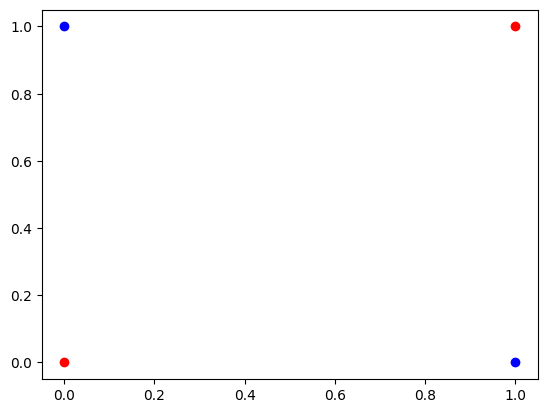

<Figure size 640x480 with 0 Axes>

In [46]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

[[ 1.]
 [ 1.]
 [-1.]
 [-1.]]


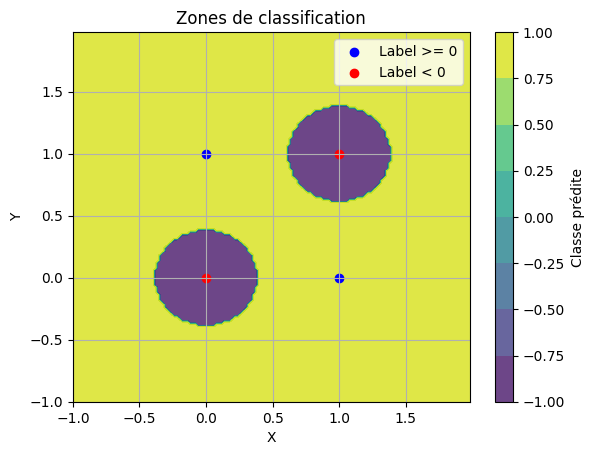

In [47]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, True)
print(predictions)

def model_classifier(points):
    return predict_MyRBF(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))

[[ 1.]
 [ 1.]
 [-1.]
 [-1.]]


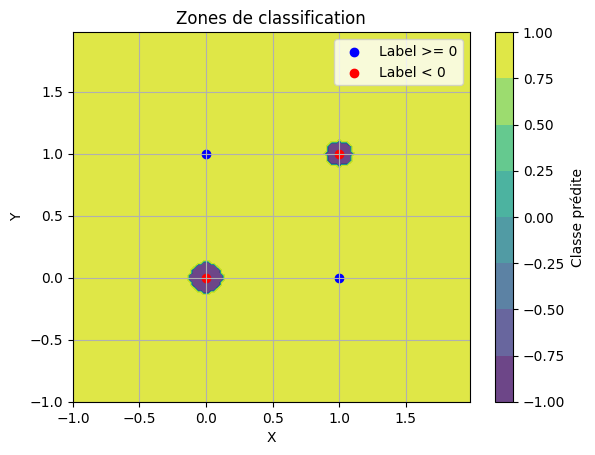

In [50]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.1)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.1, 10_000,True)

predictions = predict_MyRBF_rb(model, X, 1, True)
print(predictions)

def model_classifier(points):
    return predict_MyRBF_rb(model, np.array(points), 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))

## Linear simple 1

In [40]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])


y = np.array([
      1,
      -1,
      -1
])

In [41]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, True)
predictions

array([[ 1.],
       [-1.],
       [-1.]])

In [42]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.01)

train_MyRBF_rb(model, X, y.reshape(-1,1), 0.01,10000,False)

predict_MyRBF_rb(model, X, 1, False)

array([[ 1.],
       [-1.],
       [-1.]])

## Linear simple 2

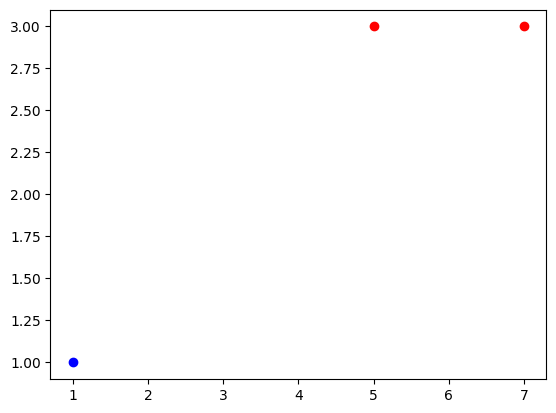

<Figure size 640x480 with 0 Axes>

In [20]:
X = np.array([
      [1, 1],
      [5, 3],
      [7, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

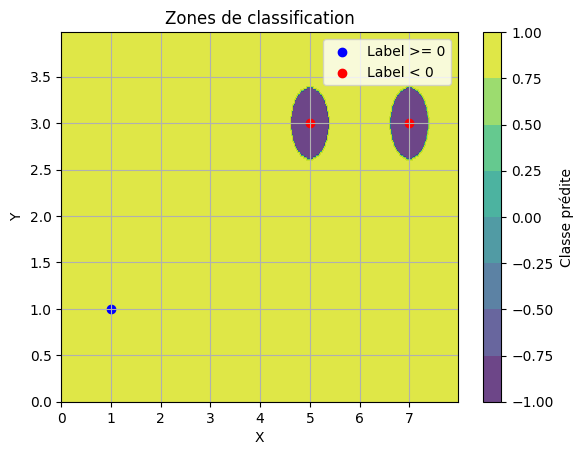

array([[ 1.],
       [-1.],
       [-1.]])

In [28]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, True)

def model_classifier(points):
    return predict_MyRBF(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))
predictions

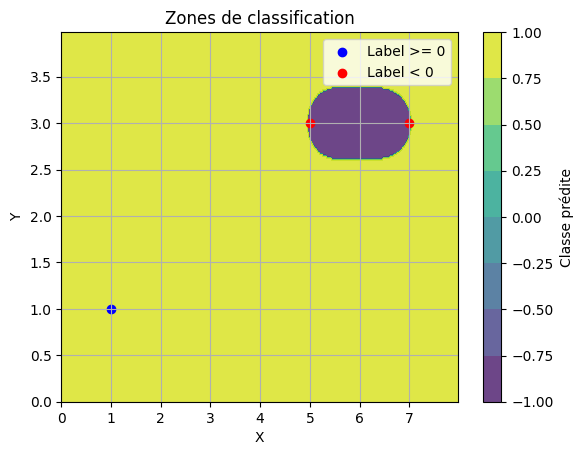

array([[ 1.],
       [-1.],
       [-1.]])

In [27]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 1)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.001,10_000,True)

def model_classifier(points):
    return predict_MyRBF_rb(model, np.array(points), 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))

predict_MyRBF_rb(model, np.array(X), 1, True)

## Linear Multiple

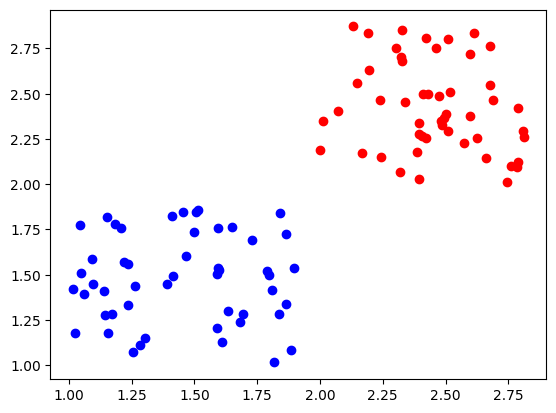

<Figure size 640x480 with 0 Axes>

In [41]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

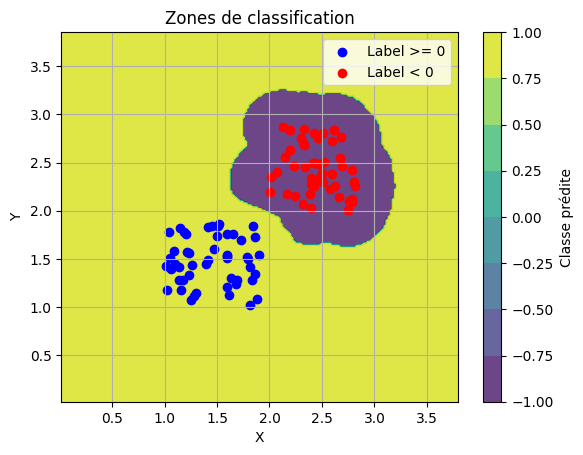

In [42]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, y)

predictions = predict_MyRBF(model, X, 1, True)

def model_classifier(points):
    return predict_MyRBF(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, y)

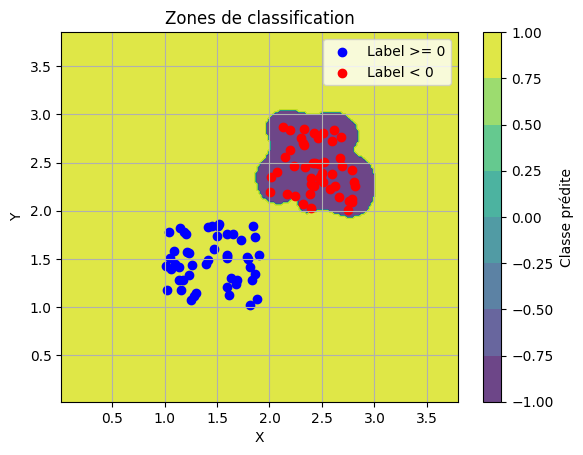

In [43]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.1)

train_MyRBF_rb(model, X, y, 1, 10_000,True)

def model_classifier(points):
    return predict_MyRBF_rb(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, y)

## Cross

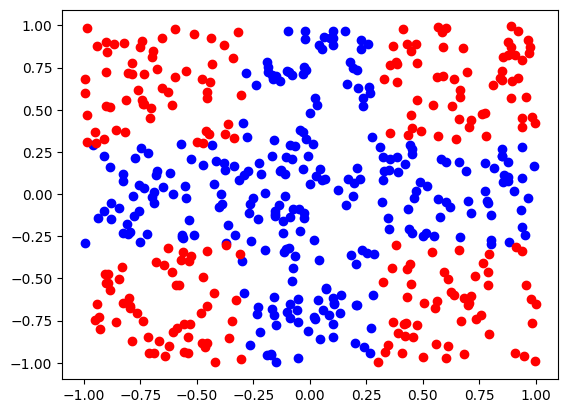

<Figure size 640x480 with 0 Axes>

In [45]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

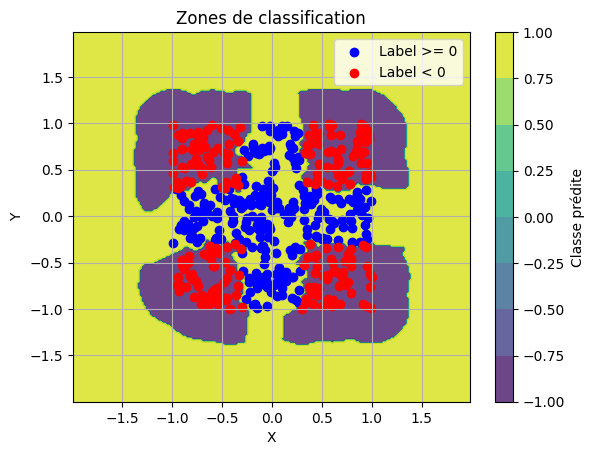

In [52]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, True)

def model_classifier(points):
    return predict_MyRBF(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))

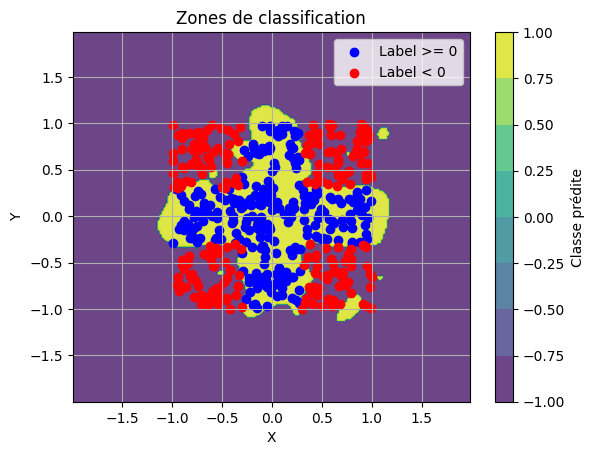

In [55]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.1)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.01, 1_000,True)

def model_classifier(points):
    return predict_MyRBF_rb(model, points, 1, True)
    
afficher_zones_classification_1(model_classifier, X, Y.reshape(-1,1))

## Multi Linear 3 classes

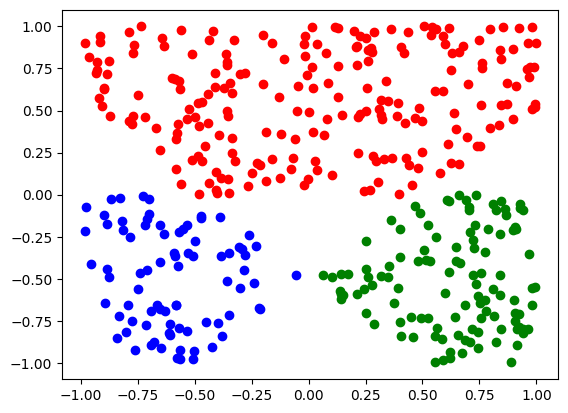

<Figure size 640x480 with 0 Axes>

In [51]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [0, 0, 0]for p in X])

X = X[[not np.all(arr == [0, 0, 0]) for arr in Y]]
Y = Y[[not np.all(arr == [0, 0, 0]) for arr in Y]]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


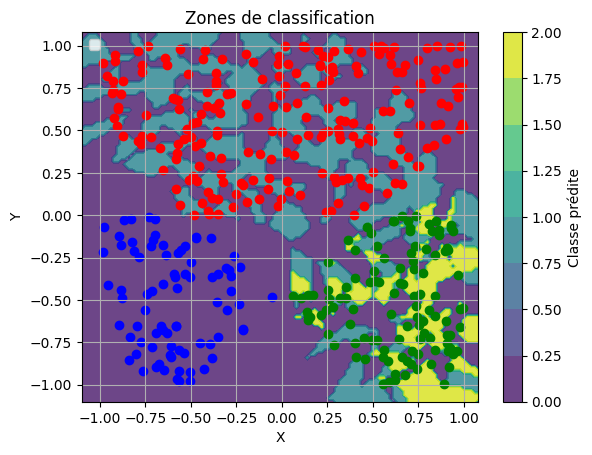

In [52]:
## RBF Classique ##
model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y)

predictions = predict_MyRBF(model, X, 3, True)

def model_classifier(points):
    return predict_MyRBF(model, points, 3, True)
    
afficher_zones_classification_2(model_classifier, X, Y)

## Multi-Cross

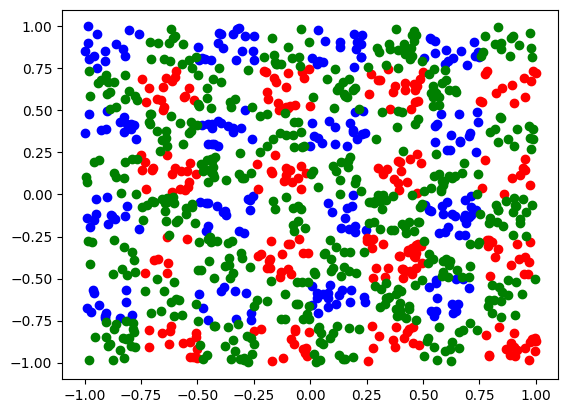

<Figure size 640x480 with 0 Axes>

In [32]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [0, 0, 1] for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


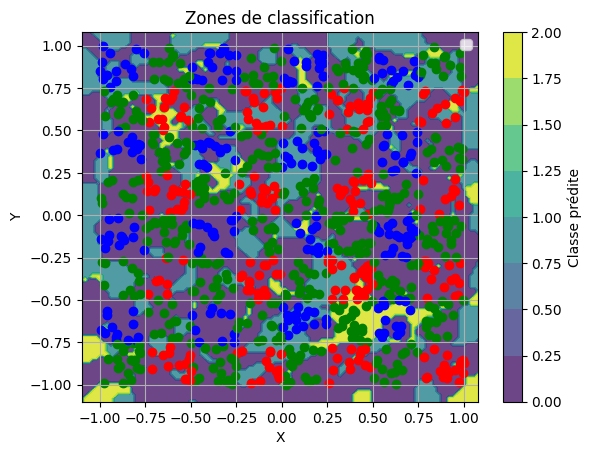

In [33]:
## RBF Classique ##

model = create_MyRBF(X, 0.1)

train_MyRBF(model, X, Y)

predictions = predict_MyRBF(model, X, 3, True)

def model_classifier(points):
    return predict_MyRBF(model, points, 3, True)
    
afficher_zones_classification_2(model_classifier, X, Y)

## Régression

## Linear Simple 2D

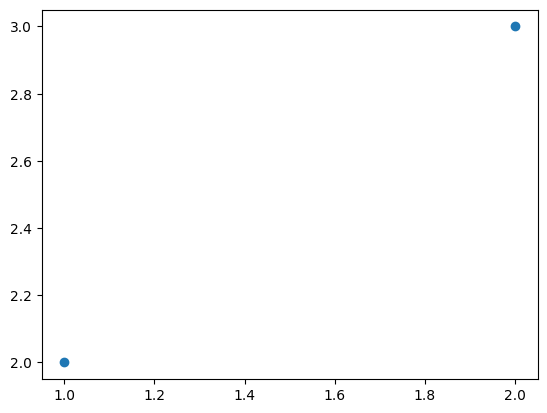

<Figure size 640x480 with 0 Axes>

In [99]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

plt.scatter(X,Y)
plt.show()
plt.clf()

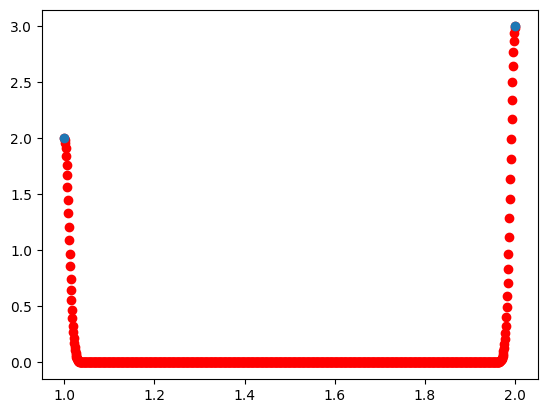

<Figure size 640x480 with 0 Axes>

In [100]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, False)

points = np.linspace(1,2,num=1000)
plot_line = predict_MyRBF(model, points.reshape(-1,1), 1, False)
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

plt.scatter(points, plot_line, c='red')
plt.scatter(X,Y)
plt.show()
plt.clf()

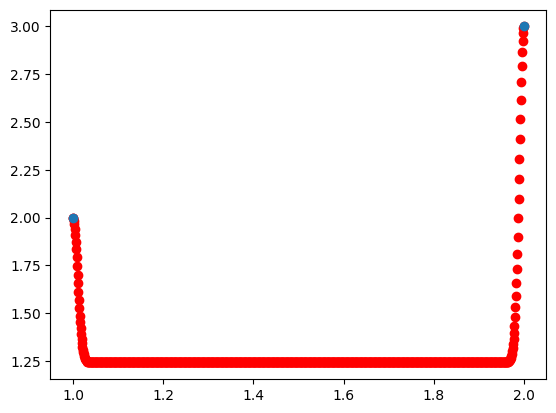

<Figure size 640x480 with 0 Axes>

In [101]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.01)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.01,1000,False)



points = np.linspace(1,2,num=1000)
plot_line = predict_MyRBF_rb(model, points.reshape(-1,1), 1, False)
plt.scatter(points, plot_line, c='red')
plt.scatter(X,Y)
plt.show()
plt.clf()

## Non Linear Simple 2D

In [54]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

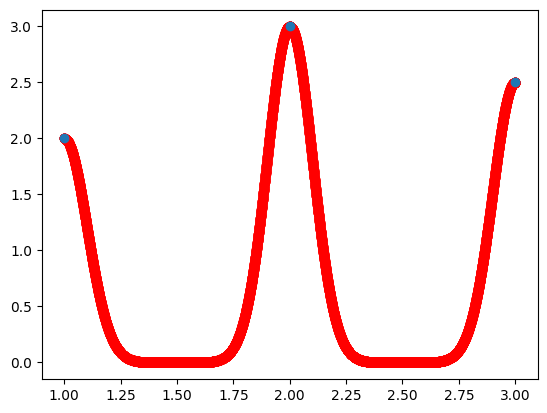

<Figure size 640x480 with 0 Axes>

In [57]:
## RBF Classique ##

model = create_MyRBF(X, 0.1)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, False)

points = np.linspace(1,3,num=10000)

plot_line = predict_MyRBF(model, points.reshape(-1,1), 1, False)

plt.scatter(points, plot_line, c='red')
plt.scatter(X,Y)
plt.show()
plt.clf()

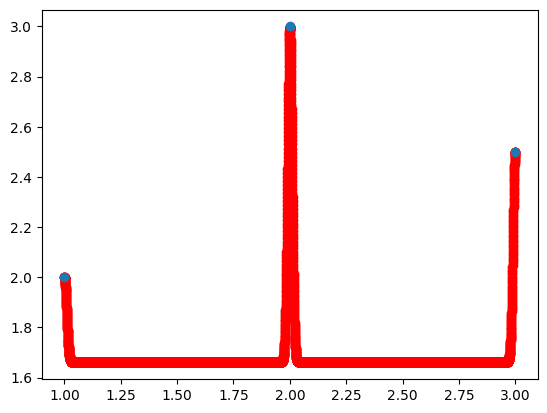

<Figure size 640x480 with 0 Axes>

In [109]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.01)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.01,1000,False)

points = np.linspace(1,3,num=10000)
plot_line = predict_MyRBF_rb(model, points.reshape(-1,1), 1, False)
plt.scatter(points, plot_line, c='red')
plt.scatter(X,Y)
plt.show()
plt.clf()

## Linear Simple 3D

/tmp/ipykernel_2210350/961943981.py:14: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


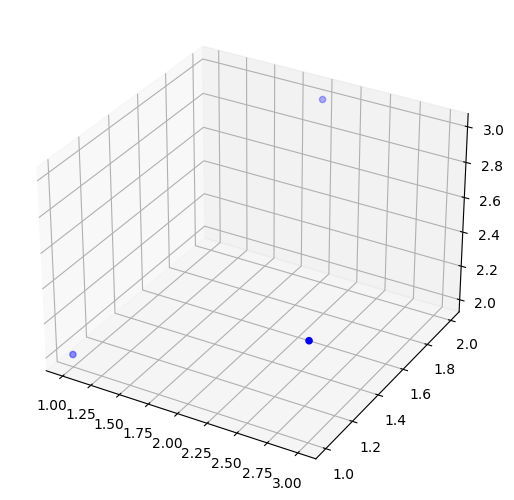

<Figure size 640x480 with 0 Axes>

In [127]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y, c='blue')
plt.show()
plt.clf()

/tmp/ipykernel_2210350/2186698591.py:18: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


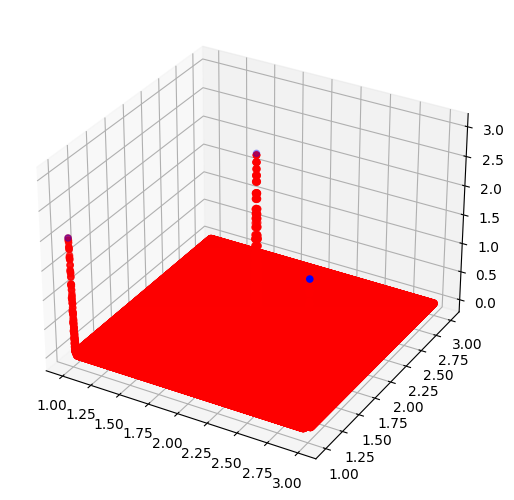

<Figure size 640x480 with 0 Axes>

In [138]:
## RBF Classique ##

model = create_MyRBF(X, 0.01)

train_MyRBF(model, X, Y.reshape(-1,1))

predictions = predict_MyRBF(model, X, 1, False)

points_x = np.linspace(1,3,num=1000)
points_y = np.linspace(1,3,num=1000)

xx, yy = np.meshgrid(points_x,points_y)
points = np.c_[xx.ravel(), yy.ravel()]

plot_line = predict_MyRBF(model, points, 1, False)

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(points[:,0],points[:,1],plot_line, c='red')
ax.scatter(X[:,0],X[:,1],Y, c='blue')
plt.show()
plt.clf()

/tmp/ipykernel_2210350/767808690.py:18: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


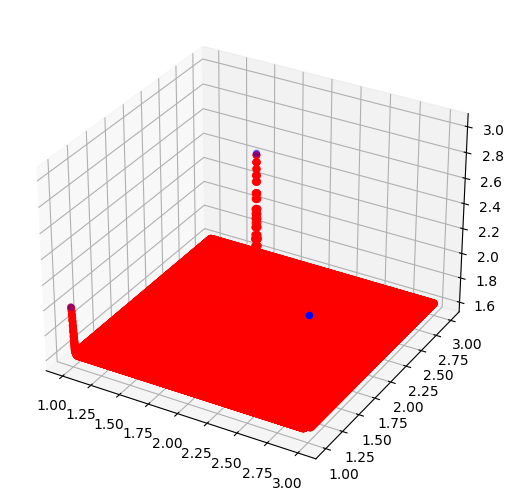

<Figure size 640x480 with 0 Axes>

In [141]:
## RBF Rosenblatt ##

model = create_MyRBF_rb(X, 1, 0.01)

train_MyRBF_rb(model, X, Y.reshape(-1,1), 0.01,1000,False)

predictions = predict_MyRBF_rb(model, X, 1, False)

points_x = np.linspace(1,3,num=1000)
points_y = np.linspace(1,3,num=1000)

xx, yy = np.meshgrid(points_x,points_y)
points = np.c_[xx.ravel(), yy.ravel()]

plot_line = predict_MyRBF_rb(model, points, 1, False)

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(points[:,0],points[:,1],plot_line, c='red')
ax.scatter(X[:,0],X[:,1],Y, c='blue')
plt.show()
plt.clf()

# Test du MLP

In [3]:
my_lib.train_MyMLP.argtypes = [ctypes.c_void_p, 
                               
                               ctypes.POINTER(ctypes.c_double), # X_train 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), # y_train 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), # X_test 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.POINTER(ctypes.c_double), # y_test 
                               ctypes.c_int32, ctypes.c_int32,
                               
                               ctypes.c_double, # learning_rate
                               ctypes.c_int32,  # nb_iter
                               ctypes.c_bool]   # is_classification

# Définition des types d'arguments et de retour pour la fonction predict_MyMLP
my_lib.predict_MyMLP.argtypes = [ctypes.c_void_p,
                                 
                                 ctypes.POINTER(ctypes.c_double),
                                 ctypes.c_int32, ctypes.c_int32,
                                 
                                 ctypes.c_bool]

my_lib.predict_MyMLP.restype = ctypes.POINTER(ctypes.c_double)

def create_MyMLP(npl):
    npl_len = len(npl)
    c_npl = (ctypes.c_int32 * npl_len)(*npl)
    model = my_lib.create_MyMLP(c_npl, npl_len)
    return model

def train_MyMLP(model, X_train, y_train, X_test, y_test, learning_rate, nb_iter, is_classification):
    X_train_shape_0 = len(X_train)
    X_train_shape_1 = len(X_train[0])
    X_train = np.array(X_train, np.float64).flatten()
    c_X_train = np.ctypeslib.as_ctypes(X_train)

    y_train_shape_0 = len(y_train)
    y_train_shape_1 = len(y_train[0])
    y_train = np.array(y_train, np.float64).flatten()
    c_y_train = np.ctypeslib.as_ctypes(y_train)

    X_test_shape_0 = len(X_test)
    X_test_shape_1 = len(X_test[0])
    X_test = np.array(X_test, np.float64).flatten()
    c_X_test = np.ctypeslib.as_ctypes(X_test)

    y_test_shape_0 = len(y_test)
    y_test_shape_1 = len(y_test[0])
    y_test = np.array(y_test, np.float64).flatten()
    c_y_test = np.ctypeslib.as_ctypes(y_test)

    my_lib.train_MyMLP(model,
                       c_X_train,
                       X_train_shape_0, X_train_shape_1,
                       
                       c_y_train,
                       y_train_shape_0, y_train_shape_1,
                       
                       c_X_test,
                       X_test_shape_0, X_test_shape_1,
                       
                       c_y_test,
                       y_test_shape_0, y_test_shape_1,
                       
                       learning_rate,
                       nb_iter,
                       is_classification)

def predict_MyMLP(model, input, pred_size, is_classification):
    input_shape_0 = len(input)
    input_shape_1 = len(input[0])
    input = np.array(input, np.float64).flatten()
    c_input = np.ctypeslib.as_ctypes(input)

    p_predictions = my_lib.predict_MyMLP(model, c_input,
                                         input_shape_0, input_shape_1,
                                         is_classification)

    predictions = np.ctypeslib.as_array(p_predictions, (input_shape_0 * pred_size,)).reshape(input_shape_0, pred_size)
    return predictions

def save_MyMLP(model, path):
    path_bytes = path.encode('utf-8')
    c_path = (ctypes.c_uint8 * len(path_bytes))(*path_bytes)
    my_lib.save_MyMLP(model, c_path, len(path_bytes))

def load_MyMLP(path):
    path_bytes = path.encode('utf-8')
    c_path = (ctypes.c_uint8 * len(path_bytes))(*path_bytes)
    model = my_lib.load_MyMLP(c_path, len(path_bytes))
    return model

def get_train_losses(model):
    p_losses = my_lib.get_train_losses(model)
    return np.ctypeslib.as_array(p_losses, shape=(nb_iter,))

def get_test_losses(model):
    p_losses = my_lib.get_test_losses(model)
    return np.ctypeslib.as_array(p_losses, shape=(nb_iter,))

In [6]:
# Créer un modèle MLP avec une structure donnée
npl = [2, 5, 1]
model = create_MyMLP(npl)

# Générer des données d'entraînement et de test
X_train = np.random.rand(10, 2).tolist()
y_train = (np.random.rand(10, 1) > 0.5).astype(np.float64).tolist()
X_test = np.random.rand(5, 2).tolist()
y_test = (np.random.rand(5, 1) > 0.5).astype(np.float64).tolist()

# Définir les paramètres d'entraînement
learning_rate = 0.01
nb_iter = 1000
is_classification = True

# # Entraîner le modèle
train_MyMLP(model, X_train, y_train, X_test, y_test, learning_rate, nb_iter, is_classification)

save_path = 'mlp_model.json'
save_MyMLP(model, save_path)

loaded_model = load_MyMLP(save_path)

# Faire des prédictions sur les données de test
predictions = predict_MyMLP(model, X_test, 1, is_classification)


# Obtenir les pertes d'entraînement et de test
train_losses = get_train_losses(model)
test_losses = get_test_losses(model)

Epoch 0: Train Loss = 1.2286232610323233, Test Loss = 1.2365574912985973
Epoch 1: Train Loss = 1.0312976448734337, Test Loss = 1.0432456042707192
Epoch 2: Train Loss = 0.8203873050781963, Test Loss = 0.8458317015757597
Epoch 3: Train Loss = 0.6245007313613969, Test Loss = 0.6713276341062533
Epoch 4: Train Loss = 0.46825993193437, Test Loss = 0.536485749456053
Epoch 5: Train Loss = 0.35841503018703047, Test Loss = 0.44156262418598435
Epoch 6: Train Loss = 0.28698505941121877, Test Loss = 0.3777383377662996
Epoch 7: Train Loss = 0.2419856733154572, Test Loss = 0.33528528462945784
Epoch 8: Train Loss = 0.21361273629059632, Test Loss = 0.3067826661115124
Epoch 9: Train Loss = 0.19535277926250713, Test Loss = 0.2872826025211325
Epoch 10: Train Loss = 0.18321932013321401, Test Loss = 0.2736415848978177
Epoch 11: Train Loss = 0.17483542227332693, Test Loss = 0.2638815173562444
Epoch 12: Train Loss = 0.16878431119491594, Test Loss = 0.25674723458403687
Epoch 13: Train Loss = 0.1642121171437467

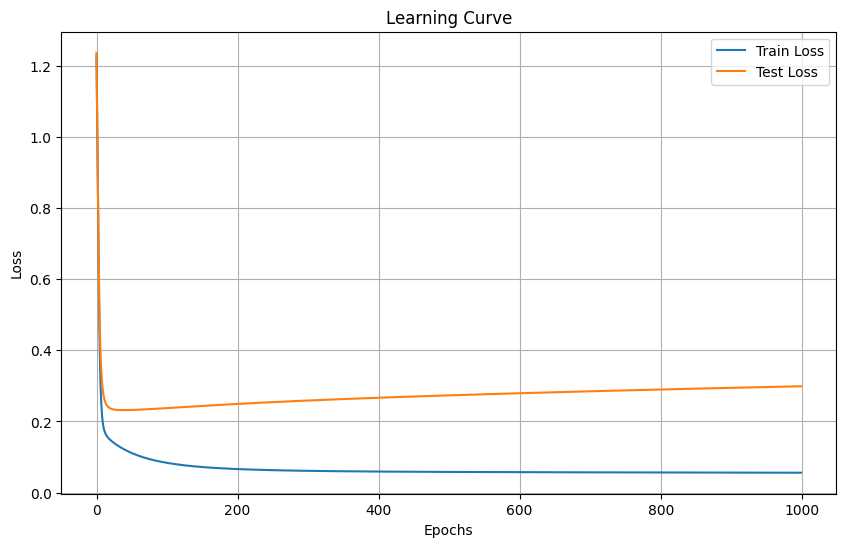

In [9]:
plot_learning_curve(train_losses, test_losses)

## Test 1

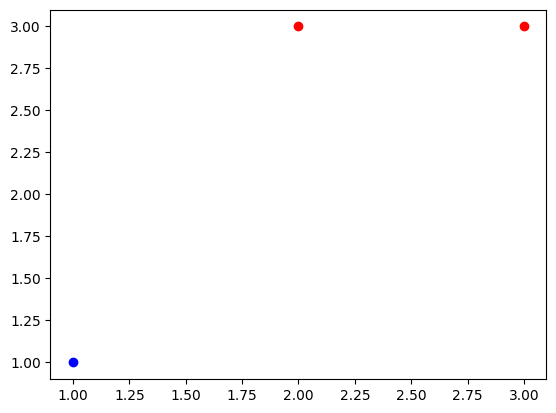

<Figure size 640x480 with 0 Axes>

In [5]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])

Y = np.array([
      1,
      -1,
      -1
])

plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

In [15]:
model = create_MyMLP([2,1])

train_MyMLP(model, X, Y.reshape(-1, 1), X, Y.reshape(-1, 1), learning_rate, 10_000, True)

predictions = predict_MyMLP(model, X, 2, True)

NameError: name 'X' is not defined

## Test 2

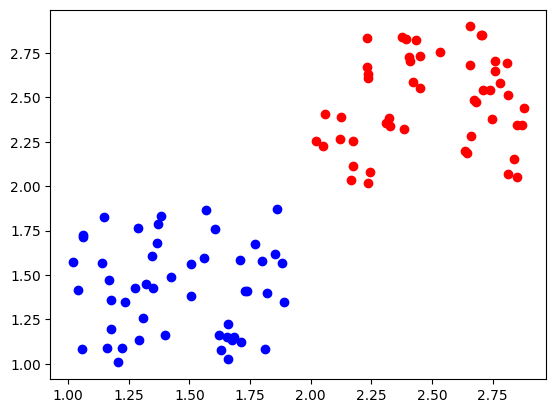

<Figure size 640x480 with 0 Axes>

In [38]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

### Test XOR

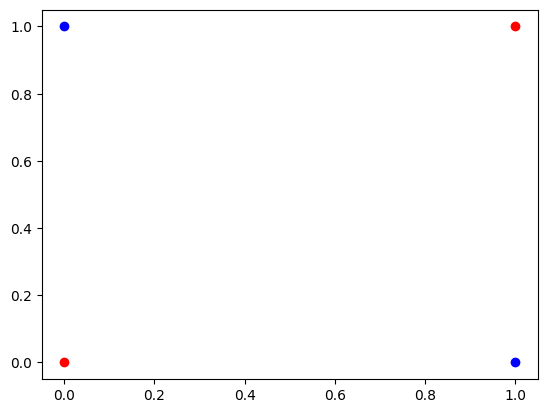

<Figure size 640x480 with 0 Axes>

In [11]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

### Test Cross

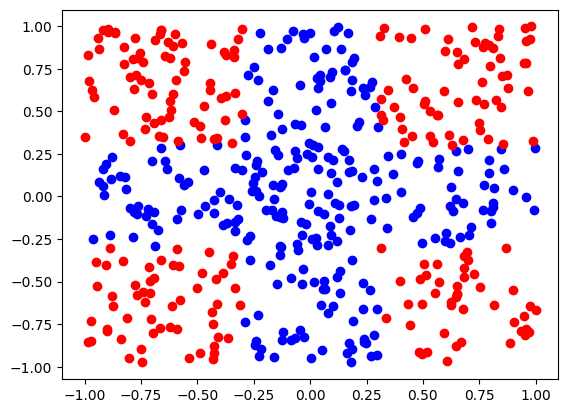

<Figure size 640x480 with 0 Axes>

In [12]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

### Test Multi Linear 3 classes :

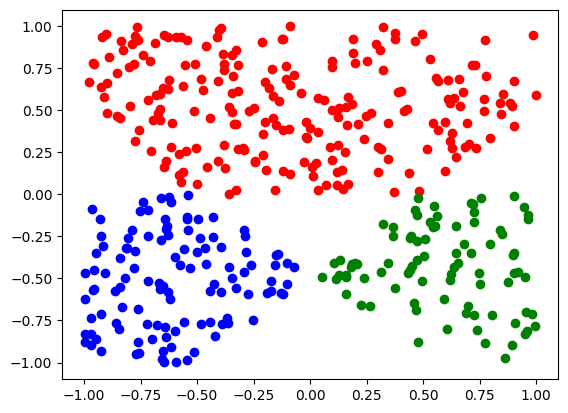

<Figure size 640x480 with 0 Axes>

In [13]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 1, 0] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [0, 0, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [0, 0, 0]for p in X])

X = X[[not np.all(arr == [0, 0, 0]) for arr in Y]]
Y = Y[[not np.all(arr == [0, 0, 0]) for arr in Y]]

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Multi Cross

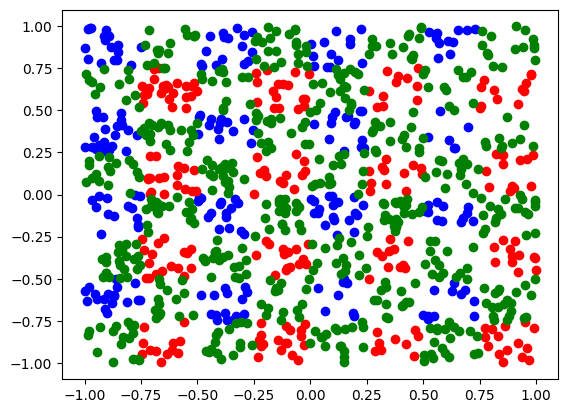

<Figure size 640x480 with 0 Axes>

In [14]:
X = np.random.random((1000, 2)) * 2.0 - 1.0
Y = np.array([[1, 0, 0] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [0, 1, 0] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [0, 0, 1] for p in X])

plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

### Régression

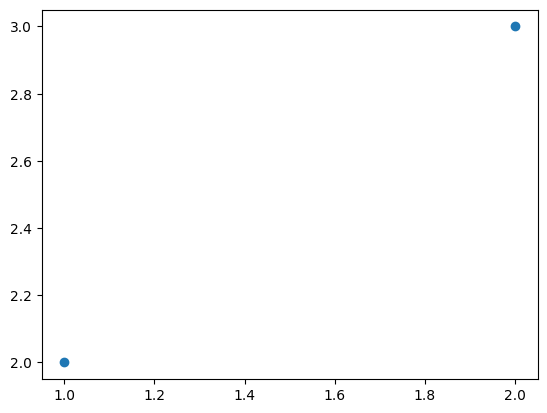

<Figure size 640x480 with 0 Axes>

In [15]:
X = np.array([
      [1],
      [2]
])
Y = np.array([
      2,
      3
])

plt.scatter(X,Y)
plt.show()
plt.clf()

### Non Linear Simple 2D :

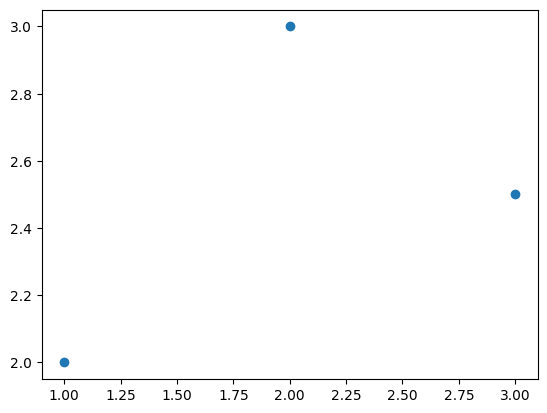

<Figure size 640x480 with 0 Axes>

In [16]:
X = np.array([
      [1],
      [2],
      [3]
])
Y = np.array([
      2,
      3,
      2.5
])

plt.scatter(X,Y)
plt.show()
plt.clf()

### Linear Simple 3D :

/tmp/ipykernel_3631674/1181262459.py:15: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


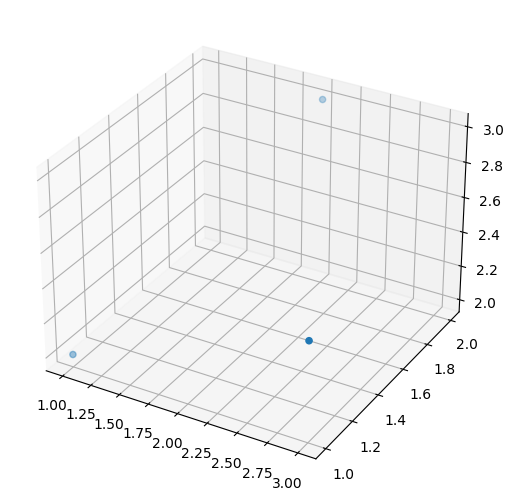

<Figure size 640x480 with 0 Axes>

In [17]:
from mpl_toolkits.mplot3d import Axes3D

X = np.array([
      [1, 1],
      [2, 2],
      [3, 1]
])
Y = np.array([
      2,
      3,
      2.5
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Linear Tricky 3D :

/tmp/ipykernel_3631674/2155744248.py:13: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


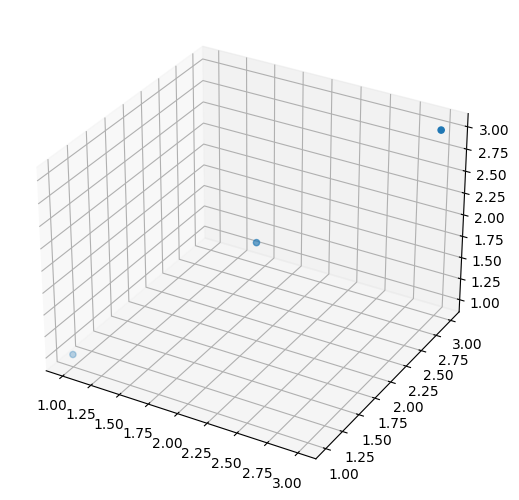

<Figure size 640x480 with 0 Axes>

In [18]:
X = np.array([
      [1, 1],
      [2, 2],
      [3, 3]
])
Y = np.array([
      1,
      2,
      3
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Non Linear Simple 3D :

/tmp/ipykernel_3631674/2655326972.py:15: MatplotlibDeprecationWarning: Axes3D(fig) adding itself to the figure is deprecated since 3.4. Pass the keyword argument auto_add_to_figure=False and use fig.add_axes(ax) to suppress this warning. The default value of auto_add_to_figure will change to False in mpl3.5 and True values will no longer work in 3.6.  This is consistent with other Axes classes.
  ax = Axes3D(fig)


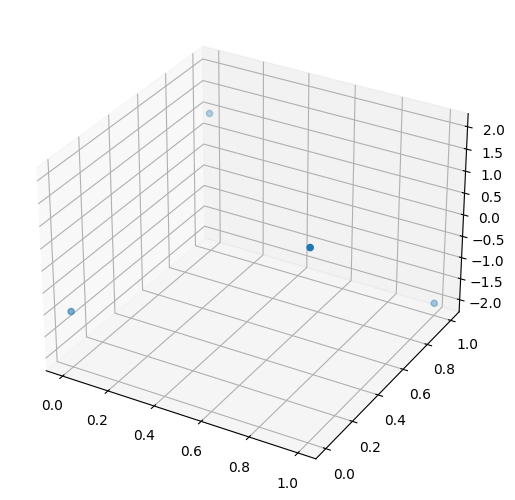

<Figure size 640x480 with 0 Axes>

In [19]:
X = np.array([
      [1, 0],
      [0, 1],
      [1, 1],
      [0, 0],
])
Y = np.array([
      2,
      1,
      -2,
      -1
])

fig = plt.figure()
ax = Axes3D(fig)
ax.scatter(X[:,0],X[:,1],Y)
plt.show()
plt.clf()

### Test sur des images

In [24]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

def load_emotions_data(path, image_size, nombre_d_images_par_classe):
    emotions = ['happy', 'neutral', 'sad']
    X = []
    y = []
    
    for label, emotion in enumerate(emotions):
        emotion_path = os.path.join(path, emotion)
        images = os.listdir(emotion_path)[:nombre_d_images_par_classe]
        
        for image_name in images:
            image_path = os.path.join(emotion_path, image_name)
            image = load_img(image_path, target_size=(image_size, image_size))
            image_array = img_to_array(image)
            X.append(image_array)
            y.append(label)
    
    X = np.array(X)
    y = to_categorical(y, num_classes=len(emotions))
    
    # Shuffle the data
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    
    return X_train, y_train, X_test, y_test


def show_images(images, labels=None, num_images=10):
    plt.figure(figsize=(20, 10))
    
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].astype('uint8'))
        plt.axis('off')
        
        if labels is not None:
            label = np.argmax(labels[i])
            emotion = ""
            if label == 0:
                emotion = "Sad"
            if label == 1:
                emotion = "Neutral"
            else:
                emotion = "Happy"
            plt.title(emotion)
    
    plt.show()

X_train shape: (21, 64, 64, 3)
y_train shape: (21, 3)
X_test shape: (9, 64, 64, 3)
y_test shape: (9, 3)


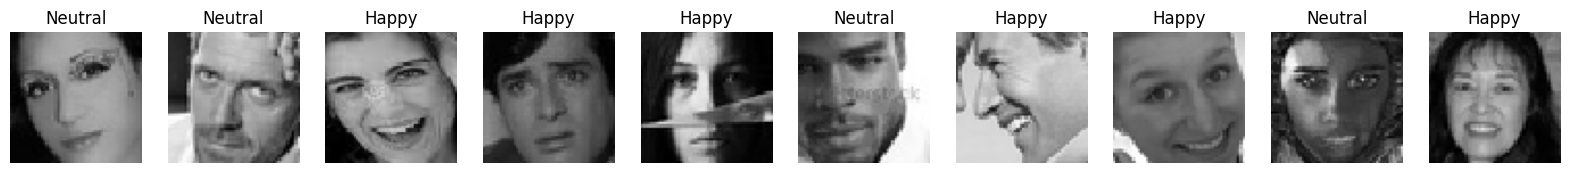

In [25]:
path = '../dataset'
image_size = 64
nombre_d_images_par_classe = 10

X_train, y_train, X_test, y_test = load_emotions_data(path, image_size, nombre_d_images_par_classe)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

show_images(X_train, y_train, 10)

In [6]:
def preprocess_images(X):
    X_normalized = X / 255.0
    X_flattened = X_normalized.reshape(X_normalized.shape[0], -1)
    return X_flattened

X_train_preprocessed = preprocess_images(X_train)
X_test_preprocessed = preprocess_images(X_test)

print(f"X_train_preprocessed shape: {X_train_preprocessed.shape}")
print(f"X_test_preprocessed shape: {X_test_preprocessed.shape}")

X_train_preprocessed shape: (21, 12288)
X_test_preprocessed shape: (9, 12288)


In [ ]:
input_size = len(X_train_preprocessed[0])

model = create_MyMLP([input_size, 3])

learning_rate = 0.01
epochs = 100_000
is_classification = True

train_MyMLP(model, 
            X_train_preprocessed, y_train, 
            X_test_preprocessed, y_test, 
            learning_rate, 
            epochs, 
            is_classification)

save_MyMLP(model, "first_model.json")

Epoch 0: Train Loss = 1.5799348784472715, Test Loss = 1.7037033626948765
Epoch 1: Train Loss = 1.4920611537293245, Test Loss = 1.7037033613598653
Epoch 2: Train Loss = 1.492061139809105, Test Loss = 1.7037033600116116
Epoch 3: Train Loss = 1.492061125721921, Test Loss = 1.7037033586499035
Epoch 4: Train Loss = 1.4920611114647524, Test Loss = 1.7037033572745246
Epoch 5: Train Loss = 1.4920610970345067, Test Loss = 1.7037033558852535
Epoch 6: Train Loss = 1.4920610824280158, Test Loss = 1.703703354481864
Epoch 7: Train Loss = 1.4920610676420343, Test Loss = 1.7037033530641252
Epoch 8: Train Loss = 1.492061052673235, Test Loss = 1.7037033516318003
Epoch 9: Train Loss = 1.4920610375182104, Test Loss = 1.7037033501846477
Epoch 10: Train Loss = 1.4920610221734667, Test Loss = 1.7037033487224198
Epoch 11: Train Loss = 1.4920610066354216, Test Loss = 1.7037033472448633
Epoch 12: Train Loss = 1.492060990900403, Test Loss = 1.703703345751719
Epoch 13: Train Loss = 1.4920609749646452, Test Loss =